In [1]:
import pandas as pd
import numpy as np

insurance = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/refs/heads/master/insurance.csv')

insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score



In [3]:
insurance_filled = insurance.dropna()

insurance_filled['region'] = insurance_filled['region'].str.lower()

FEMALE = 'female'
MALE = 'male'
sex_map = {'F': FEMALE, 'woman': FEMALE, 'man': MALE, 'M': MALE}

insurance_filled['sex'] = insurance_filled['sex'].replace(sex_map)

insurance_filled['smoker'] = (insurance_filled['smoker'] == 'yes')

insurance_filled['charges'] = insurance_filled['charges'].str.strip('$').astype('float64')

insurance_pos = insurance_filled.apply(lambda x: x.abs() if np.issubdtype(x.dtype, np.number) else x)

insurance_pos.sample(10)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11668\2850888025.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['region'] = insurance_filled['region'].str.lower()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11668\2850888025.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['sex'] = insurance_filled['sex'].replace(sex_map)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11668\2850888025.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

,age,sex,bmi,children,smoker,region,charges
484,48.0,male,34.300,3.0,False,southwest,9563.02900
1070,37.0,male,37.070,1.0,True,southeast,39871.70430
933,45.0,female,35.300,0.0,False,southwest,7348.14200
617,49.0,male,25.600,2.0,True,southwest,23306.54700
1018,54.0,female,35.815,3.0,False,northwest,12495.29085
602,56.0,female,25.300,0.0,False,southwest,11070.53500
1097,22.0,male,33.770,0.0,False,southeast,1674.63230
722,62.0,male,37.400,0.0,False,southwest,12979.35800
719,58.0,female,33.440,0.0,False,northwest,12231.61360
75,57.0,male,34.010,0.0,False,northwest,11356.66090


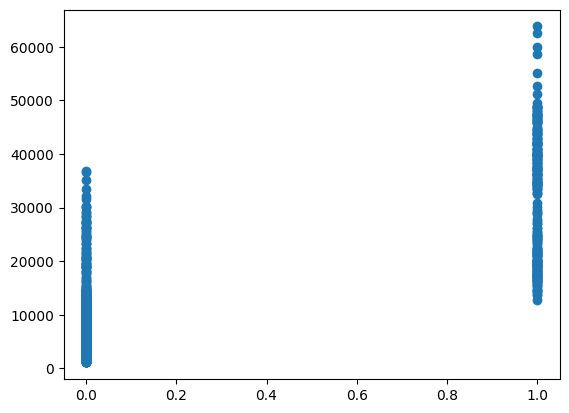

In [4]:
import matplotlib.pyplot as plt

# Task #2: Scatterplots of relationships between variables & charges
df = insurance_pos.copy()

plt.scatter(df['smoker'], df['charges'])

In [5]:
df_new = pd.get_dummies(df, prefix=['region'], columns=['region'])
df_new = df_new.drop(columns=['region_southeast'])

df_new['smoker'] = df_new['smoker'].astype('int64')

df_new['is_male'] = (df_new['sex'] == 'male').astype('int64')
df_new = df_new.drop(columns=['sex'])

df_new = df_new.dropna()
df_new.head()

,age,bmi,children,smoker,charges,region_northeast,region_northwest,region_southwest,is_male
0,19.0,27.900,0.0,1,16884.92400,False,False,True,0
1,18.0,33.770,1.0,0,1725.55230,False,False,False,1
2,28.0,33.000,3.0,0,4449.46200,False,False,False,1
3,33.0,22.705,0.0,0,21984.47061,False,True,False,1
4,32.0,28.880,0.0,0,3866.85520,False,True,False,1


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score    

# Define input and output variables
X = df_new.drop(columns=['charges'])
y = df_new['charges']

print(df_new.info())
print(y.info())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the R squared score
r2_score = r2_score(y_test, y_pred)

# Output the mean squared error
r2_score

<class 'pandas.core.frame.DataFrame'>
Index: 1207 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1207 non-null   float64
 1   bmi               1207 non-null   float64
 2   children          1207 non-null   float64
 3   smoker            1207 non-null   int64  
 4   charges           1207 non-null   float64
 5   region_northeast  1207 non-null   bool   
 6   region_northwest  1207 non-null   bool   
 7   region_southwest  1207 non-null   bool   
 8   is_male           1207 non-null   int64  
dtypes: bool(3), float64(4), int64(2)
memory usage: 69.5 KB
None
<class 'pandas.core.series.Series'>
Index: 1207 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1207 non-null   float64
dtypes: float64(1)
memory usage: 18.9 KB
None


0.7049323160872817

In [20]:
def preprocess_df(df):
    df = df.copy()

    # One-hot encode region
    df = pd.get_dummies(df, columns=['region'], drop_first=False)

    # Drop region_southeast to match training
    if 'region_southeast' in df.columns:
        df = df.drop(columns=['region_southeast'])

    # Add missing region columns
    for col in ['region_northeast', 'region_northwest', 'region_southwest']:
        if col not in df.columns:
            df[col] = 0

    # Convert smoker to int
    df['smoker'] = (df['smoker'] == 'yes').astype(float)

    # Convert sex to is_male
    df['is_male'] = (df['sex'] == 'male').astype(float)
    df = df.drop(columns=['sex'])

    # Ensure correct order
    expected_order = [
        'age', 'bmi', 'children', 'smoker',
        'region_northeast', 'region_northwest', 'region_southwest',
        'is_male'
    ]

    df = df[expected_order]

    # FIX: fill NaN values
    df = df.fillna(0)

    return df


In [24]:
val_df = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/refs/heads/master/insurance.csv')
input_df = preprocess_df(val_df)

predictions = model.predict(input_df)

validation_data = val_df.copy()

validation_data['predicted_charges'] = predictions

validation_data.loc[validation_data['predicted_charges'] < 1000, 'predicted_charges'] = 1000

validation_data.head()





,age,sex,bmi,children,smoker,region,charges,predicted_charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924,25776.376175
1,18.0,male,33.770,1.0,no,Southeast,1725.5523,3089.381454
2,28.0,male,33.000,3.0,no,southeast,$4449.462,6474.056499
3,33.0,male,22.705,0.0,no,northwest,$21984.47061,3905.536787
4,32.0,male,28.880,0.0,no,northwest,$3866.8552,5586.807995


In [17]:
model.feature_names_in_


array(['age', 'bmi', 'children', 'smoker', 'region_northeast',
       'region_northwest', 'region_southwest', 'is_male'], dtype=object)